In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("vinai/bertweet-base", use_fast=False)

# Custom Dataset
class OpinionDataset(Dataset):
    def __init__(self, texts, level1, level2, level3, senti_scores, tokenizer, max_len=128):
        self.texts = texts
        self.level1 = level1
        self.level2 = level2
        self.level3 = level3
        self.senti_scores = senti_scores  # New feature
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(self.texts[idx], truncation=True, padding='max_length',
                                  max_length=self.max_len, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label1': torch.tensor(self.level1[idx], dtype=torch.long),
            'label2': torch.tensor(-1 if pd.isna(self.level2[idx]) else self.level2[idx], dtype=torch.long),
            'label3': torch.tensor(-1 if pd.isna(self.level3[idx]) else self.level3[idx], dtype=torch.long),
            'senti_score': torch.tensor(self.senti_scores[idx], dtype=torch.float),  # New feature
            'text': self.texts[idx]
        }

# Hierarchical Model
class HierarchicalBertweet(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained("vinai/bertweet-base")
        self.dropout = nn.Dropout(0.3)
        
        # New layer to process sentiment score
        self.senti_proj = nn.Linear(1, 64)  # Project 1D score to 64D
        
        # Modified classifiers to take both BERT features and sentiment features
        self.classifier1 = nn.Linear(768 + 64, 3)  # 768 (BERT) + 64 (senti)
        self.classifier2 = nn.Linear(768 + 64, 3)
        self.classifier3 = nn.Linear(768 + 64, 4)

    def forward(self, input_ids, attention_mask, senti_score):
        # Get BERT features
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)[0][:, 0]  # CLS token
        bert_features = self.dropout(bert_output)
        
        # Process sentiment score
        senti_features = self.senti_proj(senti_score.unsqueeze(1))  # Shape: (batch_size, 64)
        senti_features = torch.relu(senti_features)
        
        # Combine features
        combined_features = torch.cat([bert_features, senti_features], dim=1)
        
        # Classifiers
        out1 = self.classifier1(combined_features)
        out2 = self.classifier2(combined_features)
        out3 = self.classifier3(combined_features)
        return out1, out2, out3

def train_and_evaluate(df, tokenizer, epochs=3, batch_size=16, folds=10):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

    all_preds1, all_labels1 = [], []
    all_preds2, all_labels2 = [], []
    all_preds3, all_labels3 = [], []

    misclassified_data = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(df['text'], df['level1'])):
        print(f"\n====== Fold {fold+1} ======")
        train_df = df.iloc[train_idx]
        val_df = df.iloc[val_idx]

        train_dataset = OpinionDataset(train_df['text'].tolist(), 
                                      train_df['level1'].tolist(),
                                      train_df['level2'].tolist(), 
                                      train_df['level3'].tolist(),
                                      train_df['senti_score'].tolist(), 
                                      tokenizer)
        val_dataset = OpinionDataset(val_df['text'].tolist(), 
                                    val_df['level1'].tolist(),
                                    val_df['level2'].tolist(), 
                                    val_df['level3'].tolist(),
                                    val_df['senti_score'].tolist(),  
                                    tokenizer)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

        model = HierarchicalBertweet().cuda()
        optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
        loss_fn = nn.CrossEntropyLoss(ignore_index=-1)
        best_score = 0.0
        best_model_path = f"best_model_fold{fold+1}.pt"
        for epoch in range(epochs):
            model.train()
            for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
                input_ids = batch['input_ids'].cuda()
                attention_mask = batch['attention_mask'].cuda()
                label1 = batch['label1'].cuda()
                label2 = batch['label2'].cuda()
                label3 = batch['label3'].cuda()
                senti_score = batch['senti_score'].cuda()

                out1, out2, out3 = model(input_ids, attention_mask, senti_score)
                loss1 = loss_fn(out1, label1)
                loss2 = loss_fn(out2, label2)
                loss3 = loss_fn(out3, label3)
                loss = loss1 + loss2 + loss3

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Evaluation after each epoch
            model.eval()
            val_true1, val_pred1 = [], []
            val_true2, val_pred2 = [], []
            val_true3, val_pred3 = [], []

            with torch.no_grad():
                for batch in val_loader:
                    input_ids = batch['input_ids'].cuda()
                    attention_mask = batch['attention_mask'].cuda()
                    label1 = batch['label1']
                    label2 = batch['label2']
                    label3 = batch['label3']
                    senti_score = batch['senti_score'].cuda()

                    out1, out2, out3 = model(input_ids, attention_mask, senti_score)
                    pred1 = torch.argmax(out1, dim=1).cpu()
                    pred2 = torch.argmax(out2, dim=1).cpu()
                    pred3 = torch.argmax(out3, dim=1).cpu()

                    val_true1.extend(label1.tolist())
                    val_pred1.extend(pred1.tolist())

                    for i in range(len(label1)):
                        if label1[i] == 2:
                            val_true2.append(label2[i].item())
                            val_pred2.append(pred2[i].item())
                            if label2[i] == 0:
                                val_true3.append(label3[i].item())
                                val_pred3.append(pred3[i].item())

            lev1_acc = accuracy_score(val_true1, val_pred1)
            lev1_f1 = f1_score(val_true1, val_pred1, average='weighted')
            combined_score = lev1_acc + lev1_f1

            print(f"\n📊 Epoch {epoch+1} Evaluation:")
            print(f"  Level 1 Accuracy: {lev1_acc:.4f}, F1: {lev1_f1:.4f}, Score: {combined_score:.4f}")
            if val_true2:
                print(f"  Level 2 Accuracy: {accuracy_score(val_true2, val_pred2):.4f}, F1: {f1_score(val_true2, val_pred2, average='weighted'):.4f}")
            if val_true3:
                print(f"  Level 3 Accuracy: {accuracy_score(val_true3, val_pred3):.4f}, F1: {f1_score(val_true3, val_pred3, average='weighted'):.4f}")

            if combined_score > best_score:
                best_score = combined_score
                torch.save(model.state_dict(), best_model_path)
                print(f"💾 Best model saved at Epoch {epoch+1} with score = {combined_score:.4f}")

        # Load best model and evaluate
        model.load_state_dict(torch.load(best_model_path))
        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].cuda()
                attention_mask = batch['attention_mask'].cuda()
                senti_score = batch['senti_score'].cuda()
                label1 = batch['label1']
                label2 = batch['label2']
                label3 = batch['label3']
                texts = batch['text']

                out1, out2, out3 = model(input_ids, attention_mask, senti_score)
                pred1 = torch.argmax(out1, dim=1).cpu()
                pred2 = torch.argmax(out2, dim=1).cpu()
                pred3 = torch.argmax(out3, dim=1).cpu()

                for i in range(len(texts)):
                    all_preds1.append(pred1[i].item())
                    all_labels1.append(label1[i].item())

                    if label1[i] == 2:
                        all_preds2.append(pred2[i].item())
                        all_labels2.append(label2[i].item())

                        if label2[i] == 0:
                            all_preds3.append(pred3[i].item())
                            all_labels3.append(label3[i].item())

                            if label3[i].item() != pred3[i].item():
                                misclassified_data.append({
                                    "text": texts[i],
                                    "true_level1": label1[i].item(), "pred_level1": pred1[i].item(),
                                    "true_level2": label2[i].item(), "pred_level2": pred2[i].item(),
                                    "true_level3": label3[i].item(), "pred_level3": pred3[i].item()
                                })
                    elif label1[i].item() != pred1[i].item():
                        misclassified_data.append({
                            "text": texts[i],
                            "true_level1": label1[i].item(), "pred_level1": pred1[i].item()
                        })

    return (all_labels1, all_preds1,
            all_labels2, all_preds2,
            all_labels3, all_preds3,
            pd.DataFrame(misclassified_data),
            model)

def print_results(y_true1, y_pred1, y_true2, y_pred2, y_true3, y_pred3, misclassified_df):
    print("\n===== Level 1 Results =====")
    print(classification_report(y_true1, y_pred1, target_names=["NOISE", "OBJECTIVE", "SUBJECTIVE"]))
    print(confusion_matrix(y_true1, y_pred1))

    print("\n===== Level 2 Results (SUBJECTIVE only) =====")
    print(classification_report(y_true2, y_pred2, target_names=["NEUTRAL", "NEGATIVE", "POSITIVE"]))
    print(confusion_matrix(y_true2, y_pred2))

    print("\n===== Level 3 Results (NEUTRAL only) =====")
    print(classification_report(y_true3, y_pred3, target_names=["NEUTRAL", "QUESTIONS", "ADS", "MISC"]))
    print(confusion_matrix(y_true3, y_pred3))

    print(f"\nTotal misclassified examples: {len(misclassified_df)}")
    print(misclassified_df.head())

    # Optional: Heatmaps
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, cm, title in zip(axes, 
                             [confusion_matrix(y_true1, y_pred1),
                              confusion_matrix(y_true2, y_pred2),
                              confusion_matrix(y_true3, y_pred3)],
                             ["Level 1", "Level 2", "Level 3"]):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(f"{title} Confusion Matrix")
    plt.tight_layout()
    plt.show()


====== Fold 1 ======


Epoch 1: 100%|██████████| 218/218 [00:44<00:00,  4.94it/s]



📊 Epoch 1 Evaluation:
  Level 1 Accuracy: 0.5907, F1: 0.5866, Score: 1.1773
  Level 2 Accuracy: 0.7768, F1: 0.7100
  Level 3 Accuracy: 0.6667, F1: 0.5752
💾 Best model saved at Epoch 1 with score = 1.1773


Epoch 2: 100%|██████████| 218/218 [00:44<00:00,  4.94it/s]



📊 Epoch 2 Evaluation:
  Level 1 Accuracy: 0.6088, F1: 0.6092, Score: 1.2180
  Level 2 Accuracy: 0.7946, F1: 0.7400
  Level 3 Accuracy: 0.7024, F1: 0.6445
💾 Best model saved at Epoch 2 with score = 1.2180


...

Epoch 2: 100%|██████████| 218/218 [00:44<00:00,  4.94it/s]



📊 Epoch 2 Evaluation:
  Level 1 Accuracy: 0.6416, F1: 0.6416, Score: 1.2832
  Level 2 Accuracy: 0.6964, F1: 0.6505
  Level 3 Accuracy: 0.6835, F1: 0.6471
💾 Best model saved at Epoch 2 with score = 1.2832


Epoch 3: 100%|██████████| 218/218 [00:44<00:00,  4.94it/s]



📊 Epoch 3 Evaluation:
  Level 1 Accuracy: 0.6675, F1: 0.6667, Score: 1.3342
  Level 2 Accuracy: 0.7232, F1: 0.6877
  Level 3 Accuracy: 0.6582, F1: 0.6076
💾 Best model saved at Epoch 3 with score = 1.3342

===== Level 1 Results =====
              precision    recall  f1-score   support

       NOISE       0.72      0.54      0.62      1204
   OBJECTIVE       0.70      0.74      0.72      1532
  SUBJECTIVE       0.62      0.74      0.67      1123

    accuracy                           0.68      3859
   macro avg       0.68      0.67      0.67      3859
weighted avg       0.68      0.68      0.68      3859

[[ 653  284  267]
 [ 149 1135  248]
 [ 105  191  827]]

===== Level 2 Results (SUBJECTIVE only) =====
              precision    recall  f1-score   support

     NEUTRAL       0.81      0.93      0.87       810
    NEGATIVE       0.62      0.14      0.23        70
    POSITIVE       0.62      0.47      0.54       243

    accuracy                           0.78      1123
   macro av

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


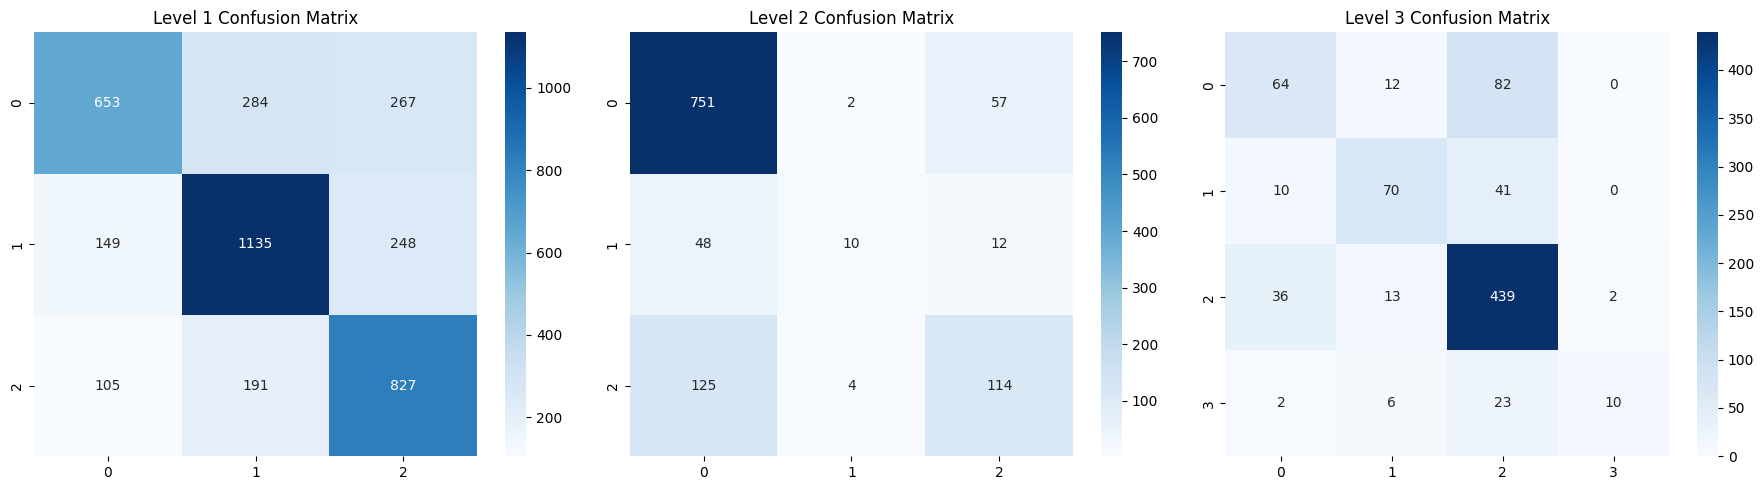

In [5]:
df = pd.read_csv("/kaggle/input/task1-sentifeature/twitter_train_senti.csv")
df.rename(columns={
    "Tweet": "text",
    "Level 1": "level1",
    "Level 2": "level2",
    "Level 3": "level3"
}, inplace=True)
(y1, p1, y2, p2, y3, p3, misclassified_df,model) = train_and_evaluate(df, tokenizer)
print_results(y1, p1, y2, p2, y3, p3, misclassified_df)

In [8]:
# model1 = HierarchicalBertweet()
# model1.load_state_dict(torch.load("/kaggle/working/best_model_fold9.pt"))
# model1.cuda()
test_df = pd.read_csv("/kaggle/input/task1-sentifeature/twitter_test_senti.csv")
test_df.rename(columns={
    "Tweet": "text",
    "Level 1": "level1",
    "Level 2": "level2",
    "Level 3": "level3"
}, inplace=True)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from collections import Counter

def print_classwise_accuracy(y_true, y_pred, label_names, level_name):
    cm = confusion_matrix(y_true, y_pred)
    correct_per_class = cm.diagonal()
    total_per_class = cm.sum(axis=1)
    print(f"\nClass-wise Accuracy for {level_name}:")
    for i, label in enumerate(label_names):
        acc = 100.0 * correct_per_class[i] / total_per_class[i] if total_per_class[i] > 0 else 0.0
        print(f"  {label:<20} : {acc:.2f}% ({correct_per_class[i]}/{total_per_class[i]})")
        
def evaluate_on_test(model, test_df, tokenizer, batch_size=16):
    test_dataset = OpinionDataset(test_df['text'].tolist(),
                                   test_df['level1'].tolist(),
                                   test_df['level2'].tolist(),
                                   test_df['level3'].tolist(),
                                   test_df['senti_score'].tolist(),
                                   tokenizer)
    
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    model.eval()
    model.cuda()
    
    y_true1, y_pred1 = [], []
    y_true2, y_pred2 = [], []
    y_true3, y_pred3 = [], []

    label1_names = ["NOISE", "OBJECTIVE", "SUBJECTIVE"]
    label2_names = ["NEUTRAL", "NEGATIVE", "POSITIVE"]
    label3_names = ["NEUTRAL SENTIMENT", "QUESTIONS", "ADVERTISEMENTS", "MISCELLANEOUS"]
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].cuda()
            attention_mask = batch['attention_mask'].cuda()
            label1 = batch['label1']
            label2 = batch['label2']
            label3 = batch['label3']
            senti_score = batch['senti_score'].cuda()

            out1, out2, out3 = model(input_ids, attention_mask, senti_score)
            pred1 = torch.argmax(out1, dim=1).cpu()
            pred2 = torch.argmax(out2, dim=1).cpu()
            pred3 = torch.argmax(out3, dim=1).cpu()

            y_true1.extend(label1.tolist())
            y_pred1.extend(pred1.tolist())

            for i in range(len(label1)):
                if label1[i] == 2:
                    y_true2.append(label2[i].item())
                    y_pred2.append(pred2[i].item())
                    
                    if label2[i] == 0:
                        y_true3.append(label3[i].item())
                        y_pred3.append(pred3[i].item())
    
    print("\n===== Level 1 Test Results =====")
    print("Accuracy:", accuracy_score(y_true1, y_pred1))
    print("F1 Score:", f1_score(y_true1, y_pred1, average='weighted'))
    print("Confusion Matrix:\n", confusion_matrix(y_true1, y_pred1))
    print_classwise_accuracy(y_true1, y_pred1, label1_names, "Level 1")
    
    print("\nLevel 2 Accuracy (on Level 1=2):", accuracy_score(y_true2, y_pred2))
    print("Level 2 F1 Score:", f1_score(y_true2, y_pred2, average='weighted'))
    print("Confusion Matrix - Level 2:")
    print(confusion_matrix(y_true2, y_pred2))
    print_classwise_accuracy(y_true2, y_pred2, label2_names, "Level 2")

    print("\nLevel 3 Accuracy (on Level 2=0):", accuracy_score(y_true3, y_pred3))
    print("Level 3 F1 Score:", f1_score(y_true3, y_pred3, average='weighted'))
    print("Confusion Matrix - Level 3:")
    print(confusion_matrix(y_true3, y_pred3))
    print_classwise_accuracy(y_true3, y_pred3, label3_names, "Level 3")
evaluate_on_test(model, test_df, tokenizer)


===== Level 1 Test Results =====
Accuracy: 0.6596736596736597
F1 Score: 0.6554875448196413
Confusion Matrix:
 [[ 67  35  32]
 [ 24 122  24]
 [ 15  16  94]]

Class-wise Accuracy for Level 1:
  NOISE                : 50.00% (67/134)
  OBJECTIVE            : 71.76% (122/170)
  SUBJECTIVE           : 75.20% (94/125)

Level 2 Accuracy (on Level 1=2): 0.776
Level 2 F1 Score: 0.7472255667038276
Confusion Matrix - Level 2:
[[84  0  6]
 [ 6  1  1]
 [15  0 12]]

Class-wise Accuracy for Level 2:
  NEUTRAL              : 93.33% (84/90)
  NEGATIVE             : 12.50% (1/8)
  POSITIVE             : 44.44% (12/27)

Level 3 Accuracy (on Level 2=0): 0.7222222222222222
Level 3 F1 Score: 0.685286278834666
Confusion Matrix - Level 3:
[[ 5  1 12  0]
 [ 1  8  4  0]
 [ 2  1 51  0]
 [ 0  1  3  1]]

Class-wise Accuracy for Level 3:
  NEUTRAL SENTIMENT    : 27.78% (5/18)
  QUESTIONS            : 61.54% (8/13)
  ADVERTISEMENTS       : 94.44% (51/54)
  MISCELLANEOUS        : 20.00% (1/5)


In [9]:
torch.save(model, 'tak1+k-fold+feature-twitter.pth')

In [24]:
test_df = pd.read_csv("/kaggle/input/task1-sentifeature/twitter_test_senti.csv")
test_df.rename(columns={
    "Tweet": "text",
    "Level 1": "level1",
    "Level 2": "level2",
    "Level 3": "level3"
}, inplace=True)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from collections import Counter

def print_classwise_accuracy(y_true, y_pred, label_names, level_name):
    cm = confusion_matrix(y_true, y_pred)
    correct_per_class = cm.diagonal()
    total_per_class = cm.sum(axis=1)
    print(f"\nClass-wise Accuracy for {level_name}:")
    for i, label in enumerate(label_names):
        acc = 100.0 * correct_per_class[i] / total_per_class[i] if total_per_class[i] > 0 else 0.0
        print(f"  {label:<20} : {acc:.2f}% ({correct_per_class[i]}/{total_per_class[i]})")
        
def evaluate_on_test(model, test_df, tokenizer, batch_size=16):
    test_dataset = OpinionDataset(test_df['text'].tolist(),
                                   test_df['level1'].tolist(),
                                   test_df['level2'].tolist(),
                                   test_df['level3'].tolist(),
                                   test_df['senti_score'].tolist(),
                                   tokenizer)
    
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    model.eval()
    model.cuda()
    
    y_true1, y_pred1 = [], []
    y_true2, y_pred2 = [], []
    y_true3, y_pred3 = [], []

    label1_names = ["NOISE", "OBJECTIVE", "SUBJECTIVE"]
    label2_names = ["NEUTRAL", "NEGATIVE", "POSITIVE"]
    label3_names = ["NEUTRAL SENTIMENT", "QUESTIONS", "ADVERTISEMENTS", "MISCELLANEOUS"]
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].cuda()
            attention_mask = batch['attention_mask'].cuda()
            label1 = batch['label1']
            label2 = batch['label2']
            label3 = batch['label3']
            senti_score = batch['senti_score'].cuda()

            out1, out2, out3 = model(input_ids, attention_mask, senti_score)
            pred1 = torch.argmax(out1, dim=1).cpu()
            pred2 = torch.argmax(out2, dim=1).cpu()
            pred3 = torch.argmax(out3, dim=1).cpu()

            y_true1.extend(label1.tolist())
            y_pred1.extend(pred1.tolist())

            for i in range(len(label1)):
                if label1[i] == 2:
                    y_true2.append(label2[i].item())
                    y_pred2.append(pred2[i].item())
                    
                    if label2[i] == 0:
                        y_true3.append(label3[i].item())
                        y_pred3.append(pred3[i].item())
    
    print("\n===== Level 1 Test Results =====")
    print("Accuracy:", accuracy_score(y_true1, y_pred1))
    print("F1 Score:", f1_score(y_true1, y_pred1, average='weighted'))
    print("Confusion Matrix:\n", confusion_matrix(y_true1, y_pred1))
    print_classwise_accuracy(y_true1, y_pred1, label1_names, "Level 1")
    
    print("\nLevel 2 Accuracy (on Level 1=2):", accuracy_score(y_true2, y_pred2))
    print("Level 2 F1 Score:", f1_score(y_true2, y_pred2, average='weighted'))
    print("Confusion Matrix - Level 2:")
    print(confusion_matrix(y_true2, y_pred2))
    print_classwise_accuracy(y_true2, y_pred2, label2_names, "Level 2")

    print("\nLevel 3 Accuracy (on Level 2=0):", accuracy_score(y_true3, y_pred3))
    print("Level 3 F1 Score:", f1_score(y_true3, y_pred3, average='weighted'))
    print("Confusion Matrix - Level 3:")
    print(confusion_matrix(y_true3, y_pred3))
    print_classwise_accuracy(y_true3, y_pred3, label3_names, "Level 3")

model1 = HierarchicalBertweet()
model1.load_state_dict(torch.load("/kaggle/working/best_model_fold1.pt"))
model1.cuda()
evaluate_on_test(model1, test_df, tokenizer)


===== Level 1 Test Results =====
Accuracy: 0.6993006993006993
F1 Score: 0.7005898142261777
Confusion Matrix:
 [[101  14  19]
 [ 37 106  27]
 [ 25   7  93]]

Class-wise Accuracy for Level 1:
  NOISE                : 75.37% (101/134)
  OBJECTIVE            : 62.35% (106/170)
  SUBJECTIVE           : 74.40% (93/125)

Level 2 Accuracy (on Level 1=2): 0.768
Level 2 F1 Score: 0.7388337598401208
Confusion Matrix - Level 2:
[[84  0  6]
 [ 4  1  3]
 [16  0 11]]

Class-wise Accuracy for Level 2:
  NEUTRAL              : 93.33% (84/90)
  NEGATIVE             : 12.50% (1/8)
  POSITIVE             : 40.74% (11/27)

Level 3 Accuracy (on Level 2=0): 0.7666666666666667
Level 3 F1 Score: 0.7537493158182814
Confusion Matrix - Level 3:
[[11  1  6  0]
 [ 3  6  4  0]
 [ 4  0 50  0]
 [ 0  1  2  2]]

Class-wise Accuracy for Level 3:
  NEUTRAL SENTIMENT    : 61.11% (11/18)
  QUESTIONS            : 46.15% (6/13)
  ADVERTISEMENTS       : 92.59% (50/54)
  MISCELLANEOUS        : 40.00% (2/5)


In [25]:
test_df = pd.read_csv("/kaggle/input/task1-sentifeature/CRYPTO_TWITTER_TEST_senti.csv")
texts = test_df['Text'].tolist()

class InferenceDataset(torch.utils.data.Dataset):
    def __init__(self, texts, senti_scores, tokenizer, max_len=128):  # Modified
        self.texts = texts
        self.senti_scores = senti_scores  # New
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(self.texts[idx],
                                padding='max_length',
                                truncation=True,
                                max_length=self.max_len,
                                return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'senti_score': torch.tensor(self.senti_scores[idx], dtype=torch.float)  # New
        }
        
test_dataset = InferenceDataset(texts, test_df['senti_score'].tolist(), tokenizer)
test_loader = DataLoader(test_dataset, batch_size=16)

preds1, preds2, preds3 = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting"):
        input_ids = batch['input_ids'].cuda()
        attention_mask = batch['attention_mask'].cuda()
        senti_score = batch['senti_score'].cuda()  

        out1, out2, out3 = model1(input_ids, attention_mask, senti_score)

        p1 = torch.argmax(out1, dim=1).cpu().tolist()
        p2 = torch.argmax(out2, dim=1).cpu().tolist()
        p3 = torch.argmax(out3, dim=1).cpu().tolist()

        preds1.extend(p1)
        preds2.extend(p2)
        preds3.extend(p3)
        
test_df["Level 1"] = preds1
test_df["Level 2"] = preds2
test_df["Level 3"] = preds3

test_df[["Text","Level 1", "Level 2", "Level 3"]].to_csv("k-fold_senti_crypto_test_twitter.csv", index=False)

Predicting: 100%|██████████| 32/32 [00:01<00:00, 16.90it/s]
